# Gold Layer Exploration

A narrative tour of the Gold layer of the football analytics pipeline.
Every query in this notebook hits real Parquet files produced by
running the pipeline against the committed sample data. The cells
are intended to be read in order — each one builds on the context
of the previous.

**To reproduce locally:**

```bash
make clean                              # wipe any prior state
PII_ENABLED=false \
  python -m src.bronze.run --batch-id notebook-demo --raw-root data/sample
PII_ENABLED=false \
  python -m src.silver.run --batch-id notebook-demo
PII_ENABLED=false \
  python -m src.gold.run --batch-id notebook-demo
jupyter notebook notebooks/gold_exploration.ipynb
```

We disable PII so player names render as plaintext for readability.
In production these are `pii_<8hex>` tokens (see ADR-0012).


## Setup

Load the Gold parquet files via DuckDB.

In [1]:
import duckdb
import pandas as pd
from pathlib import Path

# Disable noisy pandas display options
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

# Connect to an in-memory DuckDB session and register every Gold
# parquet table as a view. This matches what src/gold/duckdb_session.py
# does in production — DuckDB is our query layer over Parquet.
GOLD = Path("../data/lake/gold")
SILVER = Path("../data/lake/silver")

con = duckdb.connect(":memory:")
for table_dir in GOLD.iterdir():
    if table_dir.is_dir():
        con.execute(
            f"CREATE VIEW {table_dir.name} AS "
            f"SELECT * FROM read_parquet('{table_dir}/**/*.parquet')"
        )
for table_dir in SILVER.iterdir():
    if table_dir.is_dir():
        con.execute(
            f"CREATE VIEW {table_dir.name} AS "
            f"SELECT * FROM read_parquet('{table_dir}/**/*.parquet')"
        )

con.execute("SHOW TABLES").df()


,name
0,club_performance_metrics
1,club_season_summary
2,dim_clubs
3,dim_competitions
4,dim_date
5,dim_players
6,fact_appearances
7,fact_games
8,player_valuation_rolling_avg
9,top_players_all_time


## Who were the top scorers of the season?

The `top_scorers_by_season` Gold table is built from
`fact_appearances` aggregated by season and player, joined to
`dim_players` for the player name and `dim_clubs` for the club
name *as of the match date* (as-of-event FK resolution — see
[ADR-0008](../docs/adr/0008-cross-batch-semantics.md)).

In [2]:
con.execute("""
    SELECT 
        season,
        player_name,
        position_canonical,
        club_name_at_event AS club,
        total_goals,
        total_assists,
        appearance_count
    FROM top_scorers_by_season
    ORDER BY total_goals DESC, total_assists DESC
    LIMIT 10
""").df()


,season,player_name,position_canonical,club,total_goals,total_assists,appearance_count
0,2024-25,Robert Lewandowski,Striker,FC Barcelona,4.0,1.0,2
1,2024-25,Jude Bellingham,Attacking Midfield,Real Madrid,4.0,0.0,3
2,2024-25,Bukayo Saka,Right Winger,Arsenal FC,2.0,1.0,3
3,2024-25,Robert Sánchez,Goalkeeper,Chelsea FC,2.0,1.0,2
4,2024-25,Reece James,Right-Back,Chelsea FC,2.0,0.0,2
5,2024-25,Harry Kane,Striker,FC Bayern München,2.0,0.0,2
6,2024-25,Manuel Neuer,Goalkeeper,FC Bayern München,2.0,0.0,2
7,2024-25,Vinícius Júnior,Left Winger,Real Madrid,1.0,0.0,3
8,2024-25,Martin Ødegaard,Attacking Midfield,Arsenal FC,0.0,1.0,3
9,2024-25,David Raya,Goalkeeper,Arsenal FC,0.0,1.0,3


## How are goals distributed by playing position?

Aggregate the top-scorers table by `position_canonical`. This
column was produced in Silver via `normalise_position`
([ADR-0004](../docs/adr/0004-silver-transformations.md)) — vendor
position strings like `'Centre-Forward'`, `'CF'`, `'Striker'`
all collapse to one canonical token.

In [3]:
goals_by_position = con.execute("""
    SELECT 
        position_canonical,
        SUM(total_goals) AS goals,
        SUM(total_assists) AS assists,
        COUNT(DISTINCT player_id) AS players
    FROM top_scorers_by_season
    GROUP BY position_canonical
    ORDER BY goals DESC
""").df()
goals_by_position


,position_canonical,goals,assists,players
0,Striker,6.0,1.0,2
1,Goalkeeper,4.0,2.0,3
2,Attacking Midfield,4.0,1.0,2
3,Right Winger,2.0,1.0,1
4,Right-Back,2.0,0.0,1
5,Left Winger,1.0,0.0,1
6,Central Midfield,0.0,0.0,1
7,Defensive Midfield,0.0,0.0,1


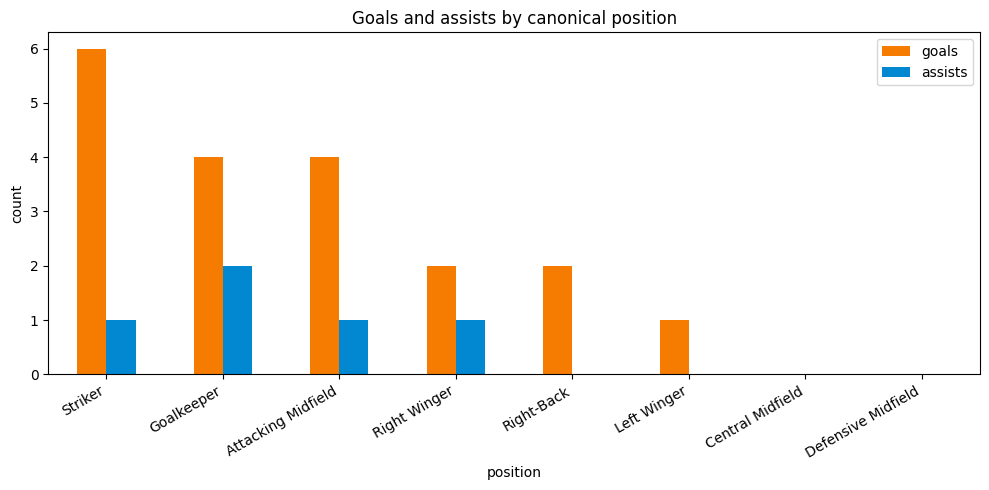

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
goals_by_position.plot(
    x="position_canonical",
    y=["goals", "assists"],
    kind="bar",
    ax=ax,
    color=["#f57c00", "#0288d1"],
)
ax.set_title("Goals and assists by canonical position")
ax.set_xlabel("position")
ax.set_ylabel("count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Which clubs had the best season?

`club_season_summary` rolls up `fact_games` to give wins, draws,
losses, goals for and against. We sort by points (3 * wins + draws)
to mimic a standings table.

In [5]:
con.execute("""
    SELECT 
        club_name,
        matches_played,
        wins,
        draws,
        losses,
        goals_for,
        goals_against,
        goal_difference,
        points
    FROM club_season_summary
    ORDER BY points DESC
""").df()


,club_name,matches_played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,Real Madrid,3,1,2,0,6.0,5.0,1.0,5
1,FC Bayern München,2,1,1,0,6.0,3.0,3.0,4
2,Arsenal FC,3,1,1,1,4.0,5.0,-1.0,4
3,Chelsea FC,2,0,1,1,1.0,3.0,-2.0,1
4,FC Barcelona,2,0,1,1,3.0,4.0,-1.0,1


## How do player valuations evolve over time?

`player_valuation_rolling_avg` carries a rolling mean of each
player's market value across observations. This is one of the
rare cases where the source data already has a time grain — every
row in `player_valuations` is a point-in-time observation, not a
current-state record. The pipeline keeps it as a fact table
rather than forcing it into SCD2 ([ADR-0005](../docs/adr/0005-scd2-implementation.md)).

In [6]:
val_trends = con.execute("""
    SELECT 
        pv.date,
        dp.name AS player,
        pv.market_value_in_eur AS value_eur,
        pv.rolling_avg_90d AS rolling_90d_avg,
        pv.rolling_sample_count AS n_observations
    FROM player_valuation_rolling_avg pv
    JOIN dim_players dp ON pv.player_id = dp.player_id
    WHERE dp.is_current = TRUE
    ORDER BY player, pv.date
""").df()
val_trends.head(15)


,date,player,value_eur,rolling_90d_avg,n_observations
0,2024-06-01,Bukayo Saka,110000000.0,1.100000e+08,1
1,2024-08-15,Bukayo Saka,115000000.0,1.125000e+08,2
2,2024-11-01,Bukayo Saka,120000000.0,1.150000e+08,3
3,2024-06-01,Harry Kane,100000000.0,1.000000e+08,1
4,2024-08-15,Harry Kane,95000000.0,9.750000e+07,2
5,2024-11-01,Harry Kane,90000000.0,9.500000e+07,3
6,2024-06-01,Jude Bellingham,170000000.0,1.700000e+08,1
7,2024-08-15,Jude Bellingham,175000000.0,1.725000e+08,2
8,2024-11-01,Jude Bellingham,180000000.0,1.750000e+08,3
9,2024-06-01,Martin Ødegaard,100000000.0,1.000000e+08,1


## How does SCD Type 2 actually look in storage?

`dim_players` keeps every version of every player as a separate
row, with `effective_date` / `end_date` defining when each
version was current. For an initial load (the sample data here),
every player has one version with a far-past `effective_date`.
Subsequent runs with changed tracked columns would create new
versions ([ADR-0005](../docs/adr/0005-scd2-implementation.md)).

In [7]:
con.execute("""
    SELECT 
        player_sk,
        player_id,
        name,
        position_canonical,
        market_value_in_eur,
        effective_date,
        end_date,
        is_current
    FROM dim_players
    ORDER BY player_id, effective_date
    LIMIT 10
""").df()


,player_sk,player_id,name,position_canonical,market_value_in_eur,effective_date,end_date,is_current
0,1,1001,Bukayo Saka,Right Winger,120000000.0,1900-01-01,9999-12-31,True
1,2,1002,Martin Ødegaard,Attacking Midfield,100000000.0,1900-01-01,9999-12-31,True
2,3,1003,Reece James,Right-Back,65000000.0,1900-01-01,9999-12-31,True
3,4,1004,David Raya,Goalkeeper,35000000.0,1900-01-01,9999-12-31,True
4,5,1005,Robert Sánchez,Goalkeeper,12000000.0,1900-01-01,9999-12-31,True
5,6,1006,Vinícius Júnior,Left Winger,200000000.0,1900-01-01,9999-12-31,True
6,7,1007,Jude Bellingham,Attacking Midfield,180000000.0,1900-01-01,9999-12-31,True
7,8,1008,Robert Lewandowski,Striker,30000000.0,1900-01-01,9999-12-31,True
8,9,1009,Pedri,Central Midfield,100000000.0,1900-01-01,9999-12-31,True
9,10,1010,Harry Kane,Striker,90000000.0,1900-01-01,9999-12-31,True


## A star-schema join: top scorer at each club

The point of a star schema is that this kind of question is just
a SQL `JOIN` and `GROUP BY`. The Gold layer's pre-aggregated
tables save us from re-running the joins on every dashboard load,
but the dimensions are still queryable for ad-hoc analysis.

In [8]:
con.execute("""
    WITH ranked AS (
        SELECT
            club_name_at_event AS club,
            player_name,
            total_goals,
            ROW_NUMBER() OVER (
                PARTITION BY club_name_at_event
                ORDER BY total_goals DESC, total_assists DESC
            ) AS rank_in_club
        FROM top_scorers_by_season
    )
    SELECT club, player_name, total_goals
    FROM ranked
    WHERE rank_in_club = 1
    ORDER BY total_goals DESC
""").df()


,club,player_name,total_goals
0,FC Barcelona,Robert Lewandowski,4.0
1,Real Madrid,Jude Bellingham,4.0
2,Chelsea FC,Robert Sánchez,2.0
3,FC Bayern München,Harry Kane,2.0
4,Arsenal FC,Bukayo Saka,2.0


## What does the pipeline say about itself?

The pipeline's metadata DB records every batch run. This is the
audit trail that powers idempotency and the DQ gate. The same
table is consulted by both host-side Airflow and the Docker
container — they agree on what's been run
([ADR-0001](../docs/adr/0001-audit-table-design.md)).

In [9]:
import sqlite3
meta = sqlite3.connect("../data/metadata.db")
pd.read_sql_query(
    "SELECT batch_id, layer, status, rows_out, "
    "started_at, finished_at FROM pipeline_runs "
    "ORDER BY started_at",
    meta,
)


,batch_id,layer,status,rows_out,started_at,finished_at
0,notebook-demo,bronze,success,74,2026-06-04T10:15:47+00:00,2026-06-04T10:15:47+00:00
1,notebook-demo,silver,success,4803,2026-06-04T10:15:48+00:00,2026-06-04T10:15:48+00:00
2,notebook-demo,gold,success,52,2026-06-04T10:15:48+00:00,2026-06-04T10:15:48+00:00


## Where to next

The Gold parquet files behind these queries are stable, partitioned,
and ready for connection from any BI tool that speaks SQL —
Superset, Metabase, Tableau, or even a Pandas notebook like this
one. The pipeline's job ends at producing Gold; the consumer chooses
the visualisation layer.

Things to explore from here:

- **Re-run the pipeline** with a different `--batch-id` and see
  how SCD2 handles changes. The `data/sample/day2/` directory has
  pre-built mutations designed to exercise the merge.
- **Browse the DQ reports** at `data/dq_reports/`. Each batch
  produces a JSON summary plus rejected-row partitions under
  `data/lake/_rejected/`.
- **Inspect the audit trail** with
  `sqlite3 data/metadata.db 'SELECT * FROM file_audit'` — every
  ingested file is recorded by checksum.
- **Trigger the DAG via Docker** (`make docker-up`) and re-run
  this notebook — the same Gold tables are produced.
